🚀 Pilotage Qubit activé. Prêt à décoller.
 Infidelity : 0.00000000
📐 Area of Pulse (Theory: Pi=3.14) : -0.0167
 fidelity according to (QuTiP) : 0.9999652314


/home/jomey/miniconda3/envs/fixed_jopt_env/lib/python3.13/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


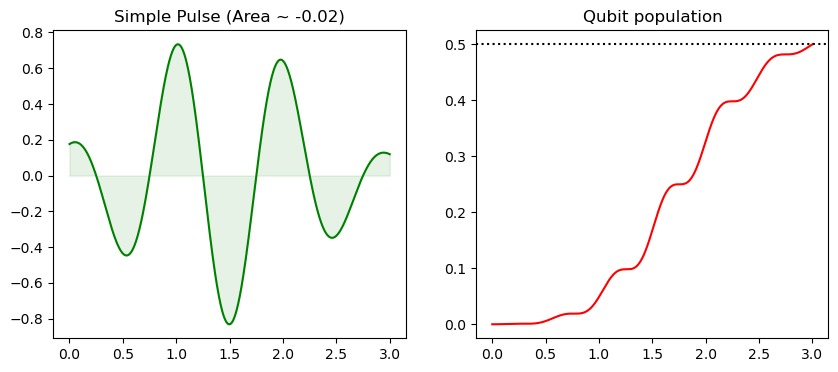

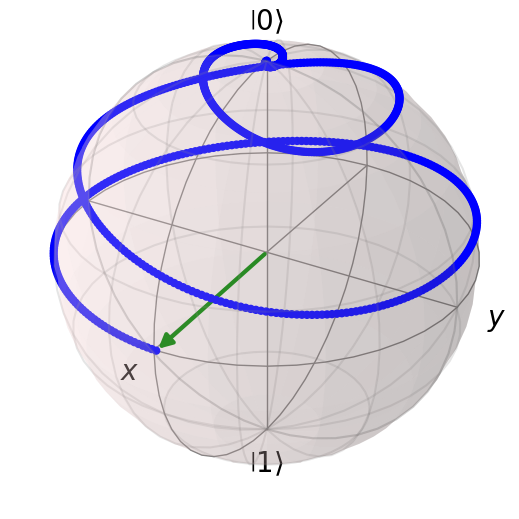

📍 Coordonnées finales de la flèche :
   X = 0.9999  (On veut 1.0000)
   Y = 0.0118  (On veut 0.0000)
   Z = 0.0002  (On veut 0.0000)


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import qutip
from qutip import basis, sigmay, sigmaz, mesolve, Bloch

import jax
import jax.numpy as jnp
from jax.scipy.linalg import expm
from scipy.optimize import minimize

# Config JAX (Toujours CPU pour Windows)
jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)

print("🚀 Pilotage Qubit activé. Prêt à décoller.")

# ==========================================
# 1. Setting Target State
# ==========================================
# Theta : Altitude (0 = Haut/Nord, pi = Bas/Sud, pi/2 = Équateur)
# Phi   : Azimut   (Rotation autour de l'axe Z)

THETA = np.pi / 2   
PHI   = 0.0         

# Formula : cos(theta/2)|0> + e^(i*phi)*sin(theta/2)|1>
target_state_qobj = (np.cos(THETA/2) * basis(2,0) + 
                     np.exp(1j * PHI) * np.sin(THETA/2) * basis(2,1))
# ==========================================
# 2. Control Parameters
# ==========================================
T = 3.0          
n_ts = 800       
dt = T / n_ts

# Hamiltonian : H = (wa/2)*Sz + u(t)*Sy
wa = 2 * np.pi   # Frequency of qubit
H_drift_jax = jnp.array((wa / 2.0) * sigmaz().full(), dtype=jnp.complex128)
H_control_jax = jnp.array(sigmay().full(), dtype=jnp.complex128)

# JAX states
psi0_jax = jnp.array(basis(2, 0).full(), dtype=jnp.complex128)
psi_targ_jax = jnp.array(target_state_qobj.full(), dtype=jnp.complex128)

n_gauss = 1  # Number of Gaussians
x0 = np.array([1.0, T/2.0, T/4.0]) # [Height, Center, Width]

def pulse_func(t, params):
    val = 0.0
    for i in range(0, len(params), 3):
        val += params[i] * jnp.exp(-(t - params[i+1])**2 / (2 * params[i+2]**2)) * jnp.cos(wa*t)
    return val

@jax.jit
def fidelity_loss(params):
    def step_scan(psi, i):
        t = i * dt
        H_t = H_drift_jax + pulse_func(t, params) * H_control_jax
        U = expm(-1j * H_t * dt)
        return jnp.dot(U, psi), None
    indices = jnp.arange(n_ts)
    final_psi, _ = jax.lax.scan(step_scan, psi0_jax, indices)
    overlap = jnp.dot(psi_targ_jax.conj().T, final_psi)
    return 1.0 - jnp.abs(jnp.squeeze(overlap))**2

# Optimisation
loss_and_grad = jax.value_and_grad(fidelity_loss)
def func_scipy(x):
    v, g = loss_and_grad(jnp.array(x))
    return np.array(v, dtype=np.float64), np.array(g, dtype=np.float64)

res = minimize(func_scipy, x0, method='BFGS', jac=True)
print(f" Infidelity : {res.fun:.8f}")

tlist = np.linspace(0, T, n_ts)
pulse_vals = [pulse_func(t, res.x) for t in tlist]

# Area below pulse curve
aire_pulse = np.trapezoid(pulse_vals, tlist)
print(f"📐 Area of Pulse (Theory: Pi=3.14) : {aire_pulse:.4f}")

# Simulation 
sim = mesolve([(wa/2.0)*sigmaz(), [sigmay(), np.array(pulse_vals)]], basis(2,0), tlist, [], [])

psi_final = sim.states[-1]
recouvrement = target_state_qobj.overlap(psi_final)
fidelite = np.abs(recouvrement)**2
print(f" fidelity according to (QuTiP) : {fidelite:.10f}")
pop_1 = qutip.expect(qutip.num(2), sim.states)



#Matplotlib and Bloch sphere

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(tlist, pulse_vals, 'g-')
plt.title(f"Simple Pulse (Area ~ {aire_pulse:.2f})")
plt.fill_between(tlist, pulse_vals, color='green', alpha=0.1) # Joli remplissage
#plt.savefig("simple_realistic_pulse.pdf", format="pdf", bbox_inches="tight")

plt.subplot(1, 2, 2)
plt.plot(tlist, pop_1, 'r-')
plt.axhline(np.sin(THETA/2)**2, c='k', ls=':')
plt.title("Qubit population")
plt.savefig("simple_realistic_area_pulse.pdf", format="pdf", bbox_inches="tight")
plt.show()

b = Bloch()

# add_states not working
expect_x = qutip.expect(qutip.sigmax(), sim.states)
expect_y = qutip.expect(qutip.sigmay(), sim.states)
expect_z = qutip.expect(qutip.sigmaz(), sim.states)

b.add_points([expect_x, expect_y, expect_z], meth='s')

vec_final = [expect_x[-1], expect_y[-1], expect_z[-1]]
b.add_vectors(vec_final)
b.save("optimized_bloch_trajectory.pdf")
b.show()
print(f"📍 Coordonnées finales de la flèche :")
print(f"   X = {expect_x[-1]:.4f}  (On veut 1.0000)")
print(f"   Y = {expect_y[-1]:.4f}  (On veut 0.0000)")
print(f"   Z = {expect_z[-1]:.4f}  (On veut 0.0000)")

🚀 Pilotage Qubit activé. Prêt à décoller.

--- Optimisation pour T = 0.010 s ---
    Infidélité Théorique (JAX pur) : 0.963598
    Fidélité Réelle (QuTiP + Bruit) : 0.6740


/home/jomey/miniconda3/envs/fixed_jopt_env/lib/python3.13/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


    Infidélité Théorique (JAX pur) : 0.963598
    Fidélité Réelle (QuTiP + Bruit) : 0.6740
    Infidélité Théorique (JAX pur) : 0.963598
    Fidélité Réelle (QuTiP + Bruit) : 0.6740

--- Optimisation pour T = 0.116 s ---
    Infidélité Théorique (JAX pur) : 0.000000
    Fidélité Réelle (QuTiP + Bruit) : 0.6952
    Infidélité Théorique (JAX pur) : 0.000000
    Fidélité Réelle (QuTiP + Bruit) : 0.6785
    Infidélité Théorique (JAX pur) : 0.000000
    Fidélité Réelle (QuTiP + Bruit) : 0.6952

--- Optimisation pour T = 0.223 s ---
    Infidélité Théorique (JAX pur) : -0.000000
    Fidélité Réelle (QuTiP + Bruit) : 0.6600
    Infidélité Théorique (JAX pur) : 0.000000
    Fidélité Réelle (QuTiP + Bruit) : 0.6051
    Infidélité Théorique (JAX pur) : 0.000000
    Fidélité Réelle (QuTiP + Bruit) : 0.6896

--- Optimisation pour T = 0.329 s ---
    Infidélité Théorique (JAX pur) : -0.000000
    Fidélité Réelle (QuTiP + Bruit) : 0.6163
    Infidélité Théorique (JAX pur) : 0.000000
    Fidélité Rée

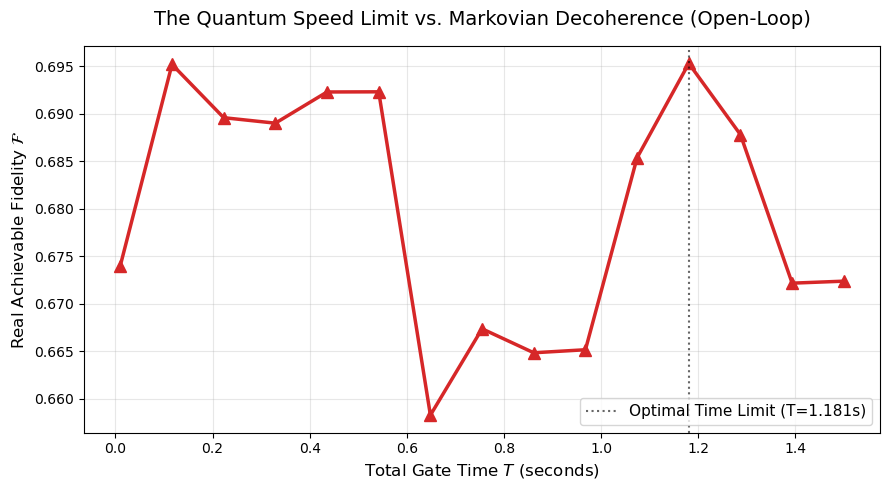

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import qutip
from qutip import basis, sigmay, sigmaz, destroy, mesolve

import jax
import jax.numpy as jnp
from jax.scipy.linalg import expm
from scipy.optimize import minimize

# Config JAX (Toujours CPU pour Windows)
jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)

print("🚀 Pilotage Qubit activé. Prêt à décoller.")

# ==========================================
# 1. Setting Target State & Physics
# ==========================================
THETA = np.pi / 2   
PHI   = 0.0         

target_state_qobj = (np.cos(THETA/2) * basis(2,0) + 
                     np.exp(1j * PHI) * np.sin(THETA/2) * basis(2,1))

wa = 0 * np.pi   # Frequency of qubit
gamma = 10.0     # Taux de relaxation markovien pour le crash test
kappa = 5.0

H_drift_jax = jnp.array((wa / 2.0) * sigmaz().full(), dtype=jnp.complex128)
H_control_jax = jnp.array(sigmay().full(), dtype=jnp.complex128)

psi0_jax = jnp.array(basis(2, 0).full(), dtype=jnp.complex128)
psi_targ_jax = jnp.array(basis(2, 1).full(), dtype=jnp.complex128)

n_ts = 100 # Résolution temporelle

# ==========================================
# 2. JAX Optimization Engine (Hors de la boucle !)
# ==========================================
def pulse_func(t, params, wa):
    # Correction : wa * t est bien à l'intérieur du cosinus
    envelope = params[0] * jnp.exp(-(t - params[1])**2 / (2 * params[2]**2))
    return envelope 

@jax.jit
def fidelity_loss(params, dt):
    def step_scan(psi, i):
        t = i * dt
        H_t = H_drift_jax + pulse_func(t, params, wa) * H_control_jax
        U = expm(-1j * H_t * dt)
        return jnp.dot(U, psi), None
    
    indices = jnp.arange(n_ts)
    final_psi, _ = jax.lax.scan(step_scan, psi0_jax, indices)
    overlap = jnp.dot(psi_targ_jax.conj().T, final_psi)
    return 1.0 - jnp.abs(jnp.squeeze(overlap))**2

loss_and_grad = jax.value_and_grad(fidelity_loss)

def func_scipy(x, dt):
    v, g = loss_and_grad(jnp.array(x), dt)
    return np.array(v, dtype=np.float64), np.array(g, dtype=np.float64)

# ==========================================
# 3. The Time Sweep Loop
# ==========================================
time_sweeps = np.linspace(0.01, 1.5, 15) 
best_fidelities_time = []

for T in time_sweeps:
    print(f"\n--- Optimisation pour T = {T:.3f} s ---")
    dt = T / n_ts
    
    # Paramètres initiaux et limites (Amplitude contrainte à +/- 40) 
    
    
    # CORRECTION CRITIQUE : Les guesses sont maintenant DANS les bounds !
    list_of_guesses = [
        [10.0, T / 2.0, T / 4.0],
        [12, T / 3.0, T / 5.0],
        [10, T / 1.5, T / 4.0]
    ]
    bounds = [(-20.0, 20.0), (0.0, T), (0.01, T)]
    best_step_fid = 0
    for guesses in list_of_guesses:
        res = minimize(func_scipy, guesses, args=(dt,), method='L-BFGS-B', jac=True, bounds=bounds)
        print(f"    Infidélité Théorique (JAX pur) : {res.fun:.6f}")

    # Vérification Physique dans QuTiP (Open-Loop Crash Test)
        tlist = np.linspace(0, T, n_ts)
        pulse_vals = [float(pulse_func(t, res.x, wa)) for t in tlist]
    
    # On introduit l'environnement markovien avec c_ops
        c_ops = [np.sqrt(gamma) * destroy(2), np.sqrt(kappa) * sigmaz()]
        sim = mesolve([(wa/2.0)*sigmaz(), [sigmay(), np.array(pulse_vals)]], 
                      basis(2,0), tlist, c_ops, [])

        psi_final_qutip = sim.states[-1]
    
    # Fidélité en système ouvert : sqrt(<targ| rho |targ>)
        fidelite = qutip.expect(qutip.ket2dm(target_state_qobj), psi_final_qutip)
        print(f"    Fidélité Réelle (QuTiP + Bruit) : {fidelite:.4f}")
        if fidelite > best_step_fid:
            best_step_fid = fidelite
    
    best_fidelities_time.append(best_step_fid)

# ==========================================
# 4. Matplotlib : Graphe QSL vs Décohérence
# ==========================================
plt.figure(figsize=(9, 5))
plt.plot(time_sweeps, best_fidelities_time, marker='^', markersize=8, color='#d62728', linewidth=2.5)

# Highlight du pic optimal
max_fid = max(best_fidelities_time)
best_time = time_sweeps[best_fidelities_time.index(max_fid)]
plt.axvline(best_time, color='black', linestyle=':', alpha=0.6, label=f'Optimal Time Limit (T={best_time:.3f}s)')

plt.title("The Quantum Speed Limit vs. Markovian Decoherence (Open-Loop)", fontsize=14, pad=15)
plt.xlabel("Total Gate Time $T$ (seconds)", fontsize=12)
plt.ylabel(r"Real Achievable Fidelity $\mathcal{F}$", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig("time-sweeps_custom_JAX.pdf", format="pdf", bbox_inches="tight")
plt.show()

🌟 Démarrage : Qubit Idéal (Référentiel Tournant)...
🧠 Optimisation en cours...


/home/jomey/miniconda3/envs/fixed_jopt_env/lib/python3.13/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)



✅ Fidélité obtenue : 0.999997


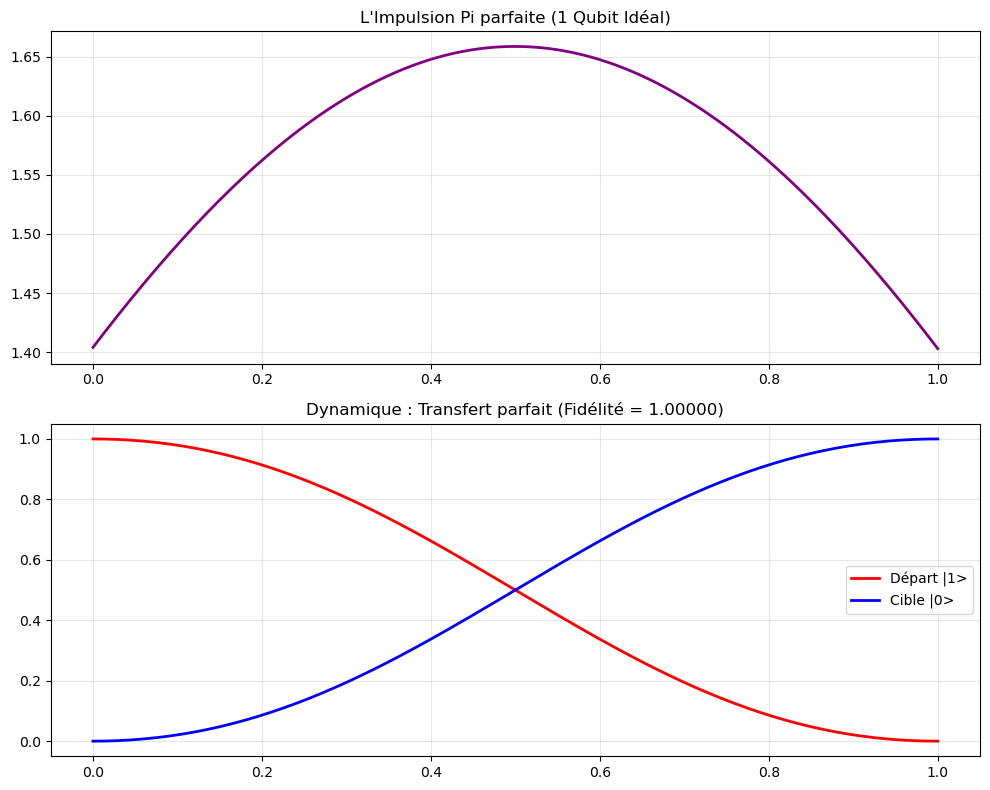

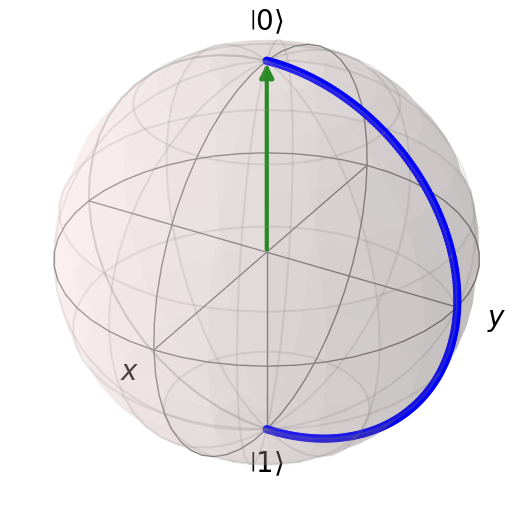

📍 Coordonnées finales de la flèche :
   X = 0.0000  (On veut 1.0000)
   Y = 0.0000  (On veut 0.0000)
   Z = 1.0000  (On veut 0.0000)


In [11]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import qutip
from qutip import basis, sigmax, sigmaz, expect
import qutip_qoc as qoc

jax.config.update("jax_platform_name", "cpu")

print("🌟 Démarrage : Qubit Idéal (Référentiel Tournant)...")

# ==========================================
# 1. SYSTÈME PHYSIQUE
# ==========================================
# rotating frame approximation
omega_q = 0.0  

H_drift = (omega_q / 2.0) * sigmaz() 
H_c = sigmay()                       

psi0 = basis(2, 1)     # start |1>
psi_targ = basis(2, 0) # target |0>

T_total = 1.0
times = np.linspace(0, T_total, 200)

@jax.jit
def gaussian_jax(t, p, **kwargs):
    return p[0] * jnp.exp(-(t - p[1])**2 / (2 * p[2]**2))

def gaussian_numpy(t, p):
    return p[0] * np.exp(-(t - p[1])**2 / (2 * p[2]**2))

H_model = [H_drift, [H_c, gaussian_jax]]

# ==========================================
# 3. OPTIMISATION JOPT
# ==========================================
guess_params = [2.0, T_total / 2.0, 0.1]
bounds = [(-10.0, 10.0), (0.0, T_total), (0.05, T_total)]

print("🧠 Optimisation en cours...")
res = qoc.optimize_pulses(
    objectives=qoc.Objective(psi0, H_model, psi_targ),
    control_parameters={"pulse_X": {"guess": guess_params, "bounds": bounds}},
    tlist=times,
    algorithm_kwargs={
        "alg": "JOPT",
        "fid_err_targ": 1e-6,
        "max_iter": 500
    }
)

# ==========================================
# 4. RESULTS
# ==========================================
print(f"\n✅ Fidélité obtenue : {1 - res.fid_err:.6f}")

opt_params = res.optimized_params[0]
opt_pulse = gaussian_numpy(times, opt_params)

opts = {"atol": 1e-10, "rtol": 1e-10}
sim = qutip.mesolve([H_drift, [H_c, opt_pulse]], psi0, times, options=opts)

pop_1 = expect(basis(2, 1) * basis(2, 1).dag(), sim.states)
pop_0 = expect(basis(2, 0) * basis(2, 0).dag(), sim.states)

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(times, opt_pulse, 'purple', lw=2)
plt.title("Pi impulsion")
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(times, pop_1, 'r', label='Start |1>', lw=2)
plt.plot(times, pop_0, 'b', label='Target |0>', lw=2)
plt.title(f"Dynamique : Transfert parfait (Fidélité = {1-res.fid_err:.5f})")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

b = Bloch()

# add_states not working
expect_x = qutip.expect(qutip.sigmax(), sim.states)
expect_y = qutip.expect(qutip.sigmay(), sim.states)
expect_z = qutip.expect(qutip.sigmaz(), sim.states)
b.add_points([expect_x, expect_y, expect_z], meth='s')

vec_final = [expect_x[-1], expect_y[-1], expect_z[-1]]
b.add_vectors(vec_final)
b.show()
print(f"📍 Coordonnées finales de la flèche :")
print(f"   X = {expect_x[-1]:.4f}  (On veut 1.0000)")
print(f"   Y = {expect_y[-1]:.4f}  (On veut 0.0000)")
print(f"   Z = {expect_z[-1]:.4f}  (On veut 0.0000)")

✅ Résultat avec 1 Gaussienne -> Infidélité : 0.00000000
   Fidelity with noise 0.5454


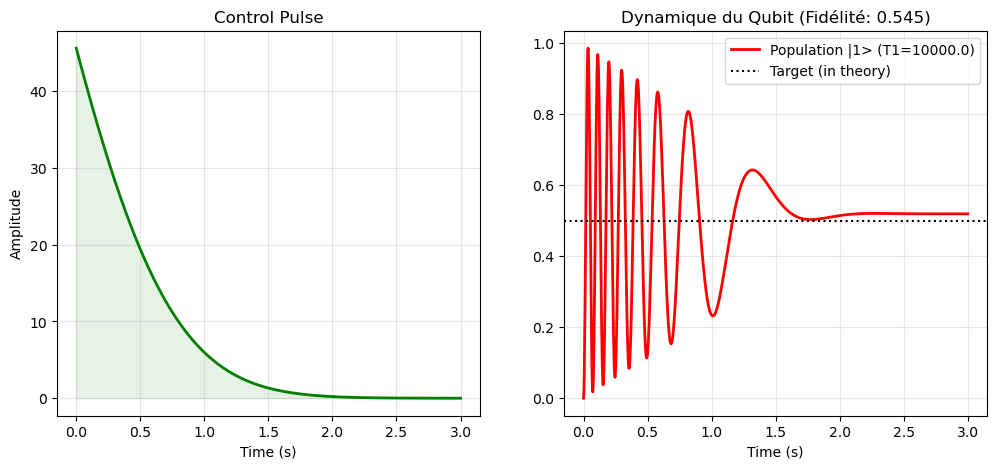

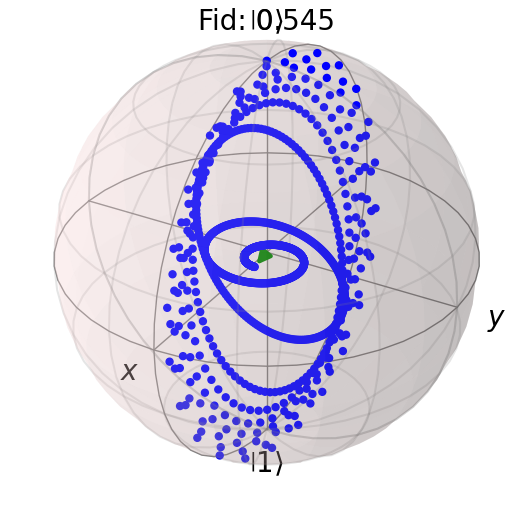

In [14]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import matplotlib.pyplot as plt
import qutip
from qutip import basis, sigmay, sigmaz, mesolve, Bloch

import jax
import jax.numpy as jnp
from jax.scipy.linalg import expm
from scipy.optimize import minimize

# Config JAX (Toujours CPU pour Windows)
jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)


THETA = np.pi / 2   
PHI   = 0.0         
# Formule : cos(theta/2)|0> + e^(i*phi)*sin(theta/2)|1>
target_state_qobj = (np.cos(THETA/2) * basis(2,0) + 
                     np.exp(1j * PHI) * np.sin(THETA/2) * basis(2,1))

# ==========================================
# 2. Parameters and system
# ==========================================
T = 3.0          
n_ts = 1000       
dt = T / n_ts

# Hamiltonian : H = (wa/2)*Sz + u(t)*Sy
wa = 2 * np.pi   #not in rotating frame
H_drift_jax = jnp.array((wa / 2.0) * sigmaz().full(), dtype=jnp.complex128)
H_control_jax = jnp.array(sigmay().full(), dtype=jnp.complex128)

# JAX states
psi0_jax = jnp.array(basis(2, 0).full(), dtype=jnp.complex128)
psi_targ_jax = jnp.array(target_state_qobj.full(), dtype=jnp.complex128)

# ==========================================
# 3. OPTIMISATION (GOAT)
# ==========================================

n_gauss = 1  
x0 = np.array([10.0, T/2.0, T/4.0]) 

def pulse_func(t, params):
    val = 0.0
    for i in range(0, len(params), 3):
        val += params[i] * jnp.exp(-(t - params[i+1])**2 / (2 * params[i+2]**2))
    return val

@jax.jit
def fidelity_loss(params):
    def step_scan(psi, i):
        t = i * dt
        H_t = H_drift_jax + pulse_func(t, params) * H_control_jax
        U = expm(-1j * H_t * dt)
        return jnp.dot(U, psi), None
    indices = jnp.arange(n_ts)
    final_psi, _ = jax.lax.scan(step_scan, psi0_jax, indices)
    overlap = jnp.dot(psi_targ_jax.conj().T, final_psi)
    return 1.0 - jnp.abs(jnp.squeeze(overlap))**2

# Optimisation
loss_and_grad = jax.value_and_grad(fidelity_loss)
def func_scipy(x):
    v, g = loss_and_grad(jnp.array(x))
    return np.array(v, dtype=np.float64), np.array(g, dtype=np.float64)

res = minimize(func_scipy, x0, method='BFGS', jac=True)
print(f"✅ Résultat avec 1 Gaussienne -> Infidélité : {res.fun:.8f}")

# ==========================================
# 4. SIMULATION COMPLÈTE (BRUIT + GRAPHES + BLOCH)
# ==========================================


T1 = 10000.0 
T2 = 2.0     
rate_dephase = 1.0 / T2


c_ops = [np.sqrt(rate_dephase) * qutip.sigmaz()]

tlist = np.linspace(0, T, n_ts)
pulse_vals = [pulse_func(t, res.x) for t in tlist]

H_opt = [(wa/2.0)*sigmaz(), [sigmay(), np.array(pulse_vals)]]

# Simulation 
sim_noisy = mesolve(H_opt, basis(2,0), tlist, c_ops, [])


pop_1 = qutip.expect(qutip.num(2), sim_noisy.states)

rho_final = sim_noisy.states[-1]
target_dm = qutip.ket2dm(target_state_qobj)
fid_noisy = qutip.expect(target_dm, rho_final)


print(f"   Fidelity with noise {fid_noisy:.4f}")

plt.figure(figsize=(12, 5))

# Graphique de Gauche : Le Laser
plt.subplot(1, 2, 1)
plt.plot(tlist, pulse_vals, 'g-', lw=2)
plt.title("Control Pulse")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.fill_between(tlist, pulse_vals, color='green', alpha=0.1)

# Graphique de Droite : La Population
plt.subplot(1, 2, 2)
plt.plot(tlist, pop_1, 'r-', lw=2, label=f'Population |1> (T1={T1})')
# Ligne pointillée pour montrer la cible théorique (sans bruit)
target_pop_theoretical = np.sin(THETA/2)**2
plt.axhline(target_pop_theoretical, c='k', ls=':', label='Target (in theory)')

plt.title(f"Dynamique du Qubit (Fidélité: {fid_noisy:.3f})")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True, alpha=0.3)
#plt.savefig("PART2_dephasing_pulse&pop.pdf", format="pdf", bbox_inches="tight")
plt.show()

b = Bloch()
b.add_annotation([0, 0, 1.2], f"Fid: {fid_noisy:.3f}")

expect_x = qutip.expect(qutip.sigmax(), sim_noisy.states)
expect_y = qutip.expect(qutip.sigmay(), sim_noisy.states)
expect_z = qutip.expect(qutip.sigmaz(), sim_noisy.states)

b.add_points([expect_x, expect_y, expect_z], meth='s') # Trajectoire
b.add_vectors([expect_x[-1], expect_y[-1], expect_z[-1]]) # Flèche finale
#b.save("PART2_dephasing_qubit.pdf")
b.show()

   Infidelity from JAX (no noise) : 0.00000004
   Infidelity QuTiP (with noise) : 0.00000150


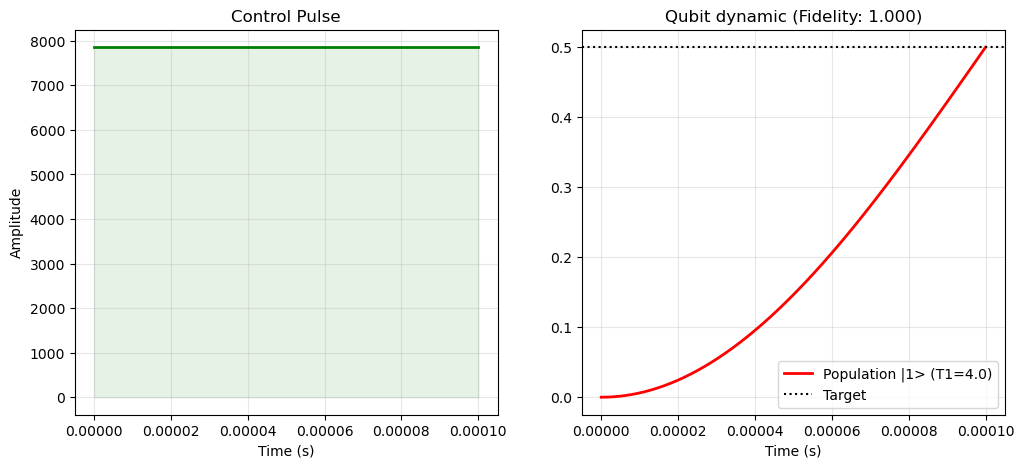

📍 Coordonnées finales de la flèche :
   X = 1.0000  (On veut 1.0000)
   Y = 0.0004  (On veut 0.0000)
   Z = 0.0000  (On veut 0.0000)


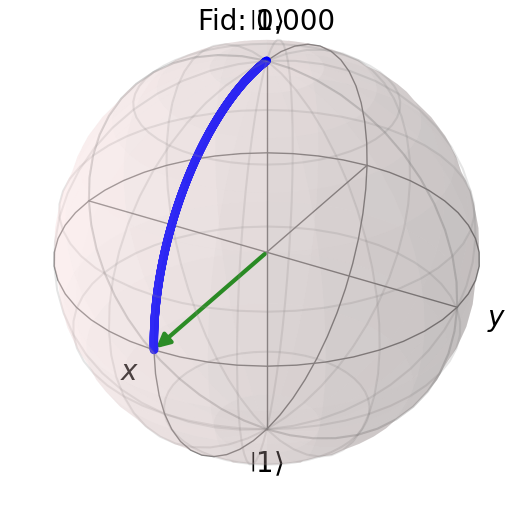

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import qutip
from qutip import basis, sigmay, sigmaz, mesolve, Bloch

import jax
import jax.numpy as jnp
from jax.scipy.linalg import expm
from scipy.optimize import minimize

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)

THETA = np.pi / 2   
PHI   = 0.0         
target_state_qobj = (np.cos(THETA/2) * basis(2,0) + 
                     np.exp(1j * PHI) * np.sin(THETA/2) * basis(2,1))

T = 0.0001          
n_ts = 1000      
dt = T / n_ts


wa = 2 * np.pi   
H_drift_jax = jnp.array((wa / 2.0) * sigmaz().full(), dtype=jnp.complex128)
H_control_jax = jnp.array(sigmay().full(), dtype=jnp.complex128)
psi0_jax = jnp.array(basis(2, 0).full(), dtype=jnp.complex128)
psi_targ_jax = jnp.array(target_state_qobj.full(), dtype=jnp.complex128)

n_gauss = 1 
x0 = np.array([100.0, T/2.0, T/4.0]) 

def pulse_func(t, params):
    val = 0.0
    for i in range(0, len(params), 3):
        val += params[i] * jnp.exp(-(t - params[i+1])**2 / (2 * params[i+2]**2))
    return val

@jax.jit
def fidelity_loss(params):
    def step_scan(psi, i):
        t = i * dt
        H_t = H_drift_jax + pulse_func(t, params) * H_control_jax
        U = expm(-1j * H_t * dt)
        return jnp.dot(U, psi), None
    indices = jnp.arange(n_ts)
    final_psi, _ = jax.lax.scan(step_scan, psi0_jax, indices)
    overlap = jnp.dot(psi_targ_jax.conj().T, final_psi)
    return 1.0 - jnp.abs(jnp.squeeze(overlap))**2

# Optimisation
loss_and_grad = jax.value_and_grad(fidelity_loss)
def func_scipy(x):
    v, g = loss_and_grad(jnp.array(x))
    return np.array(v, dtype=np.float64), np.array(g, dtype=np.float64)

res = minimize(func_scipy, x0, method='BFGS', jac=True)


T1 = 4.0   
rate = 1.0 / T1
c_ops = [np.sqrt(rate) * qutip.destroy(2)] 

tlist = np.linspace(0, T, n_ts)
pulse_vals = [pulse_func(t, res.x) for t in tlist]

H_opt = [(wa/2.0)*sigmaz(), [sigmay(), np.array(pulse_vals)]]


sim_noisy = mesolve(H_opt, basis(2,0), tlist, c_ops, [])
rho_final_bruit = sim_noisy.states[-1]

target_dm = qutip.ket2dm(target_state_qobj)
fidelite_reelle = qutip.expect(target_dm, rho_final_bruit)
infidelite_reelle = 1.0 - fidelite_reelle

print(f"   Infidelity from JAX (no noise) : {res.fun:.8f}")
print(f"   Infidelity QuTiP (with noise) : {infidelite_reelle:.8f}")


pop_1 = qutip.expect(qutip.num(2), sim_noisy.states)

rho_final = sim_noisy.states[-1]
target_dm = qutip.ket2dm(target_state_qobj)
fid_noisy = qutip.expect(target_dm, rho_final)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(tlist, pulse_vals, 'g-', lw=2)
plt.title("Control Pulse")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.fill_between(tlist, pulse_vals, color='green', alpha=0.1)

plt.subplot(1, 2, 2)
plt.plot(tlist, pop_1, 'r-', lw=2, label=f'Population |1> (T1={T1})')
target_pop_theoretical = np.sin(THETA/2)**2
plt.axhline(target_pop_theoretical, c='k', ls=':', label='Target')

plt.title(f"Qubit dynamic (Fidelity: {fid_noisy:.3f})")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


b = Bloch()
b.add_annotation([0, 0, 1.2], f"Fid: {fid_noisy:.3f}")
expect_x = qutip.expect(qutip.sigmax(), sim_noisy.states)
expect_y = qutip.expect(qutip.sigmay(), sim_noisy.states)
expect_z = qutip.expect(qutip.sigmaz(), sim_noisy.states)
b.add_points([expect_x, expect_y, expect_z], meth='s') 
b.add_vectors([expect_x[-1], expect_y[-1], expect_z[-1]]) 
print(f"📍 Coordonnées finales de la flèche :")
print(f"   X = {expect_x[-1]:.4f}  (On veut 1.0000)")
print(f"   Y = {expect_y[-1]:.4f}  (On veut 0.0000)")
print(f"   Z = {expect_z[-1]:.4f}  (On veut 0.0000)")
b.show()

   Infidelity: 0.203973
  Pulse Parameters: [1.5        0.20097093 0.17725635]
🔎 Check QuTiP (Fidélité) : 0.796004


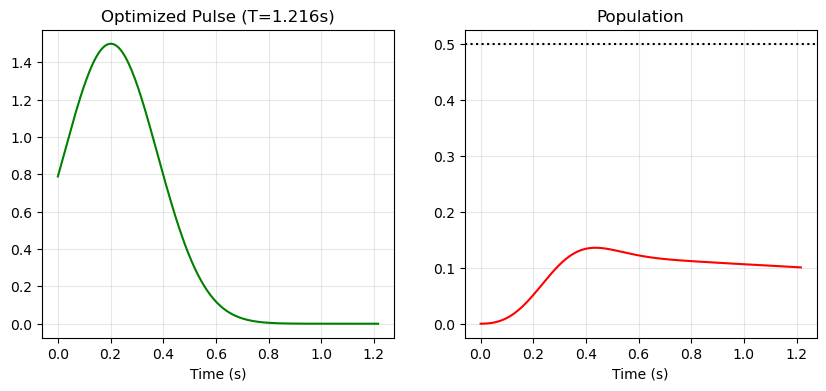

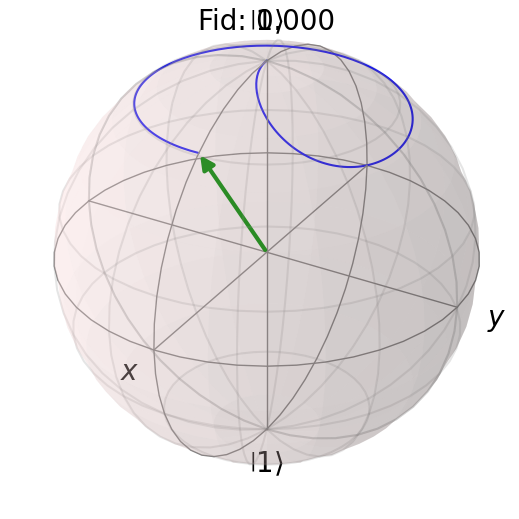

📍 Coordonnées finales de la flèche :
   X = 0.5920  (On veut 1.0000)
   Y = -0.0046  (On veut 0.0000)
   Z = 0.7988  (On veut 0.0000)


In [31]:
import jax
import jax.numpy as jnp
from jax.scipy.linalg import expm
from scipy.optimize import minimize
import numpy as np
import qutip
from qutip import basis, sigmay, sigmaz, mesolve, Bloch
import matplotlib.pyplot as plt

# Config
jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)

# ==========================================
# 1. PARAMETERS (NO FIXED TIME)
# ==========================================
#T1 = 4.0      
rate = 1/4.0
wa = 2 * np.pi


H_drift = jnp.array((wa / 2.0) * sigmaz().full(), dtype=jnp.complex128)
H_control = jnp.array(sigmay().full(), dtype=jnp.complex128)
a_op = jnp.array([[0, 1], [0, 0]], dtype=jnp.complex128) # Destroy

# Target
THETA, PHI = np.pi/2, 0.0
target_state_qobj = (np.cos(THETA/2)*basis(2,0) + np.exp(1j*PHI)*np.sin(THETA/2)*basis(2,1))
psi_targ = jnp.array(target_state_qobj.full(), dtype=jnp.complex128)

# ==========================================
# 2.  LIOUVILLIAN 
# ==========================================
def to_super_H(H):
    I = jnp.eye(2, dtype=jnp.complex128)
    return -1j * (jnp.kron(H, I) - jnp.kron(I, H.T))

def to_super_dissipator(L, rate):
    L_dag = L.conj().T
    L_dag_L = jnp.matmul(L_dag, L)
    I = jnp.eye(2, dtype=jnp.complex128)
    term1 = jnp.kron(L.conj(), L)
    term2 = -0.5 * (jnp.kron(I, L_dag_L.T) + jnp.kron(L_dag_L, I))
    return rate * (term1 + term2)

L_H_drift = to_super_H(H_drift)
L_dissip  = to_super_dissipator(a_op, rate)
L_drift_total = L_H_drift + L_dissip
L_control_super = to_super_H(H_control)

psi0 = jnp.array([1, 0], dtype=jnp.complex128)
rho0_vec = jnp.outer(psi0, psi0.conj()).reshape(4)

# ==========================================
# 3. OPTIMISATION 
# ==========================================
n_slices = 200
tau_indices = jnp.arange(n_slices)
dtau = 1.0 / n_slices


def pulse_func_norm(tau, T_val, gauss_params):
    t = tau * T_val 
    val = 0.0
    for i in range(0, len(gauss_params), 3):
        amp, mu, sig = gauss_params[i], gauss_params[i+1], gauss_params[i+2]
        val += amp * jnp.exp(-(t - mu)**2 / (2 * sig**2))
    return val

@jax.jit
def cost_function(params):
    T_curr = params[0]        
    gauss_params = params[1:] 
    
    def step(rho, i):
        tau = i * dtau
        u_val = pulse_func_norm(tau, T_curr, gauss_params)
        L_tau = (L_drift_total + u_val * L_control_super) * T_curr
        U = expm(L_tau * dtau)
        return jnp.dot(U, rho), None

    rho_final_vec, _ = jax.lax.scan(step, rho0_vec, tau_indices)
    
    rho_final = rho_final_vec.reshape((2, 2))
    temp = jnp.matmul(rho_final, psi_targ)
    overlap = jnp.dot(psi_targ.conj().T, temp)
    infidelity = 1.0 - jnp.real(overlap[0, 0])
    
    alpha_time = 1e-4 
    
    return infidelity + alpha_time * T_curr


n_gauss = 1
T_guess = 1.0
x0 = np.array([T_guess, 20.0, T_guess/2.0, T_guess/6.0])
max_amp = 1.5 
min_T = 0.05   
max_T = 5.0    

bounds = [
    (min_T, max_T),         # T
    (-max_amp, max_amp),    # Amp
    (-10.0, 10.0),          # Center 
    (0.01, 5.0)             # Width
]

loss_and_grad = jax.value_and_grad(cost_function)

def func_scipy(x):
    v, g = loss_and_grad(jnp.array(x))
    return np.array(v, dtype=np.float64), np.array(g, dtype=np.float64)

res = minimize(func_scipy, x0, method='L-BFGS-B', jac=True, bounds=bounds, tol=1e-9)

T_opt = res.x[0]
infid_opt = res.fun - 1e-4 * T_opt # On retire la pénalité pour voir la vraie infidélité


print(f"   Infidelity: {infid_opt:.6f}")
print(f"  Pulse Parameters: {res.x[1:]}")


tlist = np.linspace(0, T_opt, n_slices)
pulse_vals = [pulse_func_norm(t/T_opt, T_opt, res.x[1:]) for t in tlist]

sim = mesolve(
    [(wa/2)*sigmaz(), [sigmay(), np.array(pulse_vals)]],
    basis(2,0), tlist, 
    [np.sqrt(rate)*qutip.destroy(2)], []
)

fid_qutip = qutip.expect(qutip.ket2dm(target_state_qobj), sim.states[-1])
print(f"🔎 Check QuTiP (Fidélité) : {fid_qutip:.6f}")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(tlist, pulse_vals, 'g')
plt.title(f"Optimized Pulse (T={T_opt:.3f}s)")
plt.xlabel("Time (s)")
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(tlist, qutip.expect(qutip.num(2), sim.states), 'r')
plt.axhline(0.5, c='k', ls=':')
plt.title("Population")
plt.xlabel("Time (s)")
plt.grid(True, alpha=0.3)
#plt.savefig("Noisy_Bang-Bang.pdf", format="pdf", bbox_inches="tight")
plt.show()

b = Bloch()
b.add_annotation([0, 0, 1.2], f"Fid: {fidelite_reelle:.3f}")
expect_x = qutip.expect(qutip.sigmax(), sim.states)
expect_y = qutip.expect(qutip.sigmay(), sim.states)
expect_z = qutip.expect(qutip.sigmaz(), sim.states)
b.add_points([expect_x, expect_y, expect_z], meth='l')
b.add_vectors([expect_x[-1], expect_y[-1], expect_z[-1]])
b.show()
print(f"📍 Coordonnées finales de la flèche :")
print(f"   X = {expect_x[-1]:.4f}  (On veut 1.0000)")
print(f"   Y = {expect_y[-1]:.4f}  (On veut 0.0000)")
print(f"   Z = {expect_z[-1]:.4f}  (On veut 0.0000)")


🚀 Démarrage : Optimisation Qubit (XY Control + Time Optimal)
🎯 Objectif : Theta=1.57, Phi=0.00 (Superposition)
📉 Bruit T1 pris en compte : 4.0s
🔒 Configuration de l'optimiseur...
⏳ Calcul en cours... (Patience, JAX compile)

✅ RÉSULTAT FINAL
   Temps Optimal : 0.05319 s
   Infidélité    : 0.00075227 (Fidélité = 0.99924773)
🎨 Génération des graphiques...
🔎 Check QuTiP : 0.999248


/home/jomey/miniconda3/envs/fixed_jopt_env/lib/python3.13/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


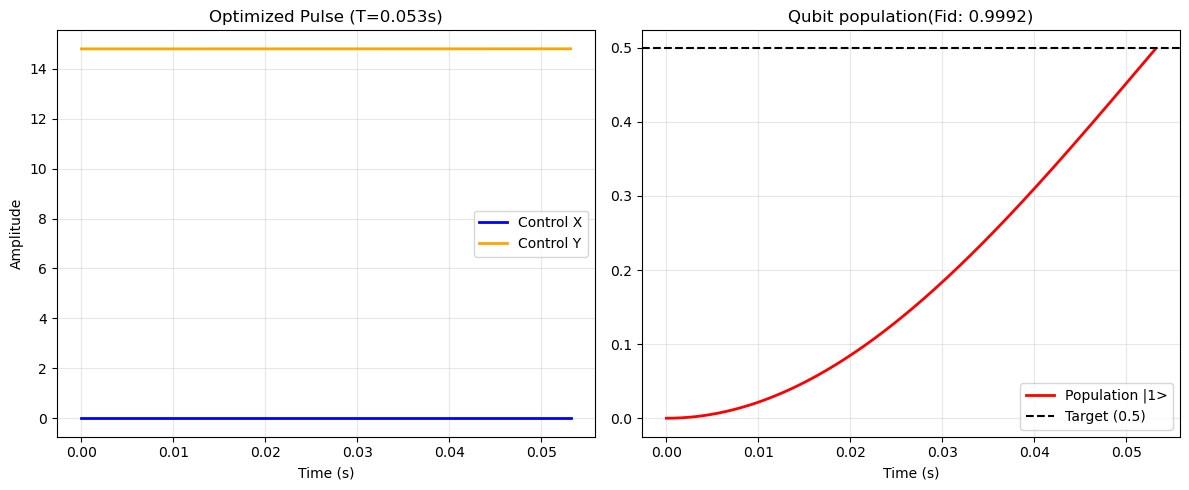

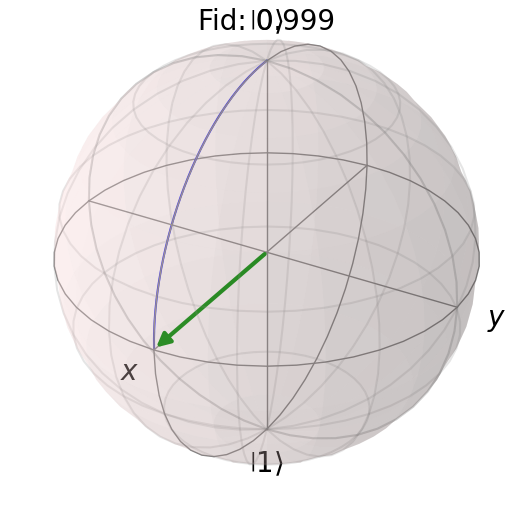

📍 Coordonnées finales de la flèche :
   X = 0.9985  (On veut 1.0000)
   Y = 0.0000  (On veut 0.0000)
   Z = 0.0032  (On veut 0.0000)


In [5]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import matplotlib.pyplot as plt
import qutip
from qutip import basis, sigmax, sigmay, sigmaz, mesolve, Bloch

import jax
import jax.numpy as jnp
from jax.scipy.linalg import expm
from scipy.optimize import minimize

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)


# ==========================================
# 1. PARAMETERS 
# ==========================================
# Noise
T1 = 4.0        # Relaxation time
rate = 1.0 / T1 # 

# Target
THETA = np.pi / 2
PHI   = 0.0
target_state_qobj = (np.cos(THETA/2)*basis(2,0) + np.exp(1j*PHI)*np.sin(THETA/2)*basis(2,1))
psi_targ_jax = jnp.array(target_state_qobj.full(), dtype=jnp.complex128)


# ==========================================
# 2. MATRIX CONSTRUCTION
# ==========================================
#Rotating frame
def to_super_H(H):
    """Transforme un Hamiltonien (2x2) en super-opérateur (4x4)."""
    I = jnp.eye(2, dtype=jnp.complex128)
    return -1j * (jnp.kron(H, I) - jnp.kron(I, H.T))

def to_super_dissipator(L, rate):
    """Crée le super-opérateur de dissipation (Lindblad)."""
    L_dag = L.conj().T
    L_dag_L = jnp.matmul(L_dag, L)
    I = jnp.eye(2, dtype=jnp.complex128)
    term1 = jnp.kron(L.conj(), L)
    term2 = -0.5 * (jnp.kron(I, L_dag_L.T) + jnp.kron(L_dag_L, I))
    return rate * (term1 + term2)


# JAX Operator
a_op = jnp.array([[0, 1], [0, 0]], dtype=jnp.complex128) # Destroy
Hx   = jnp.array(sigmax().full(), dtype=jnp.complex128)  # Control X
Hy   = jnp.array(sigmay().full(), dtype=jnp.complex128)  # Control Y


L_drift_total = to_super_dissipator(a_op, rate)

L_cx = to_super_H(Hx)
L_cy = to_super_H(Hy)

psi0 = jnp.array([1, 0], dtype=jnp.complex128)
rho0_vec = jnp.kron(psi0, psi0.conj()) # Vecteur de taille 4

# ==========================================
# 3. OPTIMISATION (JAX)
# ==========================================

n_slices = 200
tau_indices = jnp.arange(n_slices)
dtau = 1.0 / n_slices

def pulse_shape(tau, T_val, params):
    """Retourne les valeurs ux et uy à l'instant tau (normalisé)."""
    t = tau * T_val 
    ux = params[0] * jnp.exp(-(t - params[1])**2 / (2 * params[2]**2))
    uy = params[3] * jnp.exp(-(t - params[4])**2 / (2 * params[5]**2))
    return ux, uy

@jax.jit
def cost_function(params):
    T_curr = params[0]
    pulse_params = params[1:] 
    
    def step(rho, i):
        tau = i * dtau
        ux, uy = pulse_shape(tau, T_curr, pulse_params)
        L_t = (L_drift_total + ux * L_cx + uy * L_cy) * T_curr
        U = expm(L_t * dtau)
        return jnp.dot(U, rho), None
    final_rho_vec, _ = jax.lax.scan(step, rho0_vec, tau_indices)
    rho_final = final_rho_vec.reshape((2, 2))
    temp = jnp.matmul(rho_final, psi_targ_jax)
    overlap = jnp.dot(psi_targ_jax.conj().T, temp)
    infidelity = 1.0 - jnp.real(overlap[0, 0])
    pen_time = 1e-4 * T_curr
    return infidelity + pen_time




T_guess = 0.5  
x0 = np.array([
    T_guess,                        # T_total
    20.0, T_guess/2.0, T_guess/6.0, # X Axis 
     0.0, T_guess/2.0, T_guess/6.0  # Y Axis 
])

max_amp = 60.0 # Laser max
min_sig = 0.02 # Largeur min


bounds = [
    (0.05, 5.0),           
    (-max_amp, max_amp), (0.0, 5.0), (min_sig, 2.0), # X
    (-max_amp, max_amp), (0.0, 5.0), (min_sig, 2.0)  # Y
]

loss_and_grad = jax.value_and_grad(cost_function)
def func_scipy(x):
    v, g = loss_and_grad(jnp.array(x))
    return np.array(v, dtype=np.float64), np.array(g, dtype=np.float64)

# ==========================================
# 5. OPTIMISATION
# ==========================================

res = minimize(
    func_scipy, 
    x0, 
    method='L-BFGS-B', 
    jac=True, 
    bounds=bounds, 
    tol=1e-10
)

T_opt = res.x[0]
params_pulse_opt = res.x[1:]
real_infid = res.fun - 1e-4 * T_opt


print(f"   Temps Optimal : {T_opt:.5f} s")
print(f"   Infidelity    : {real_infid:.8f} (Fidélité = {1-real_infid:.8f})")



tlist = np.linspace(0, T_opt, n_slices)
ux_vals = []
uy_vals = []

for t in tlist:
    tau = t / T_opt
    ux, uy = pulse_shape(tau, T_opt, params_pulse_opt)
    ux_vals.append(float(ux))
    uy_vals.append(float(uy))

ux_vals = np.array(ux_vals)
uy_vals = np.array(uy_vals)

# H = 0*Sz + ux*Sx + uy*Sy (Rotating Frame)
H_qutip = [
    [sigmax(), ux_vals],
    [sigmay(), uy_vals]
]
c_ops = [np.sqrt(rate) * qutip.destroy(2)]

sim = mesolve(H_qutip, basis(2,0), tlist, c_ops, [])

rho_final_qutip = sim.states[-1]
fid_qutip = qutip.expect(qutip.ket2dm(target_state_qobj), rho_final_qutip)
pop_1 = qutip.expect(qutip.num(2), sim.states)

print(f" Check QuTiP : {fid_qutip:.6f}")


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(tlist, ux_vals, 'b-', label='Control X', lw=2)
ax[0].plot(tlist, uy_vals, 'orange', label='Control Y', lw=2)
ax[0].fill_between(tlist, ux_vals, color='blue', alpha=0.1)
ax[0].set_title(f"Optimized Pulse (T={T_opt:.3f}s)")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Amplitude")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(tlist, pop_1, 'r-', lw=2, label='Population |1>')
ax[1].axhline(0.5, c='k', ls='--', label='Target (0.5)')
ax[1].set_title(f"Qubit population(Fid: {fid_qutip:.4f})")
ax[1].set_xlabel("Time (s)")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig("BEST_OPTI_Noisy.pdf", format="pdf", bbox_inches="tight")
plt.show()

b = Bloch()
b.add_annotation([0, 0, 1.2], f"Fid: {fid_qutip:.3f}")
expect_x = qutip.expect(sigmax(), sim.states)
expect_y = qutip.expect(sigmay(), sim.states)
expect_z = qutip.expect(sigmaz(), sim.states)

b.add_points([expect_x, expect_y, expect_z], meth='l')
b.add_vectors([expect_x[-1], expect_y[-1], expect_z[-1]])
b.show()
print(f"📍 Coordonnées finales de la flèche :")
print(f"   X = {expect_x[-1]:.4f}  (On veut 1.0000)")
print(f"   Y = {expect_y[-1]:.4f}  (On veut 0.0000)")
print(f"   Z = {expect_z[-1]:.4f}  (On veut 0.0000)")

/home/jomey/miniconda3/envs/fixed_jopt_env/lib/python3.13/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


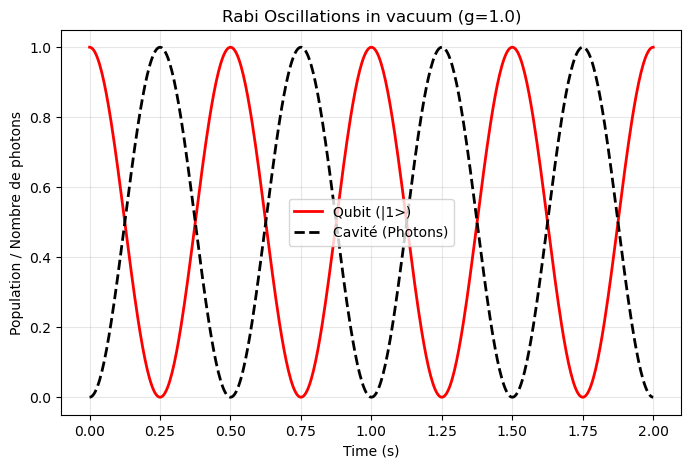

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, sigmax, sigmay, sigmaz, destroy, mesolve, tensor, qeye

N_cav = 3        
g_int = 1.0 * (2*np.pi) 
kappa = 0.0      

H_int = g_int * (tensor(destroy(2), destroy(N_cav).dag()) + 
                 tensor(destroy(2).dag(), destroy(N_cav)))
psi0 = tensor(basis(2,1), basis(N_cav,0))

T_sim = 2.0 
tlist = np.linspace(0, T_sim, 500)
sim = mesolve(H_int, psi0, tlist, [], [])

pop_qubit_1 = qutip.expect(tensor(basis(2,1)*basis(2,1).dag(), qeye(N_cav)), sim.states)
pop_cavity = qutip.expect(tensor(qeye(2), destroy(N_cav).dag()*destroy(N_cav)), sim.states)

plt.figure(figsize=(8, 5))
plt.plot(tlist, pop_qubit_1, 'r', label='Qubit (|1>)', lw=2)
plt.plot(tlist, pop_cavity, 'k--', label='Cavité (Photons)', lw=2)
plt.title(f"Rabi Oscillations in vacuum (g={g_int/(2*np.pi):.1f})")
plt.xlabel("Time (s)")
plt.ylabel("Population / Nombre de photons")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Rabi_oscillations.pdf", format="pdf", bbox_inches="tight")
plt.show()

🎮 Simulation Manuelle : Amp=1.0, Center=2.0, Width=0.5


/home/jomey/miniconda3/envs/fixed_jopt_env/lib/python3.13/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


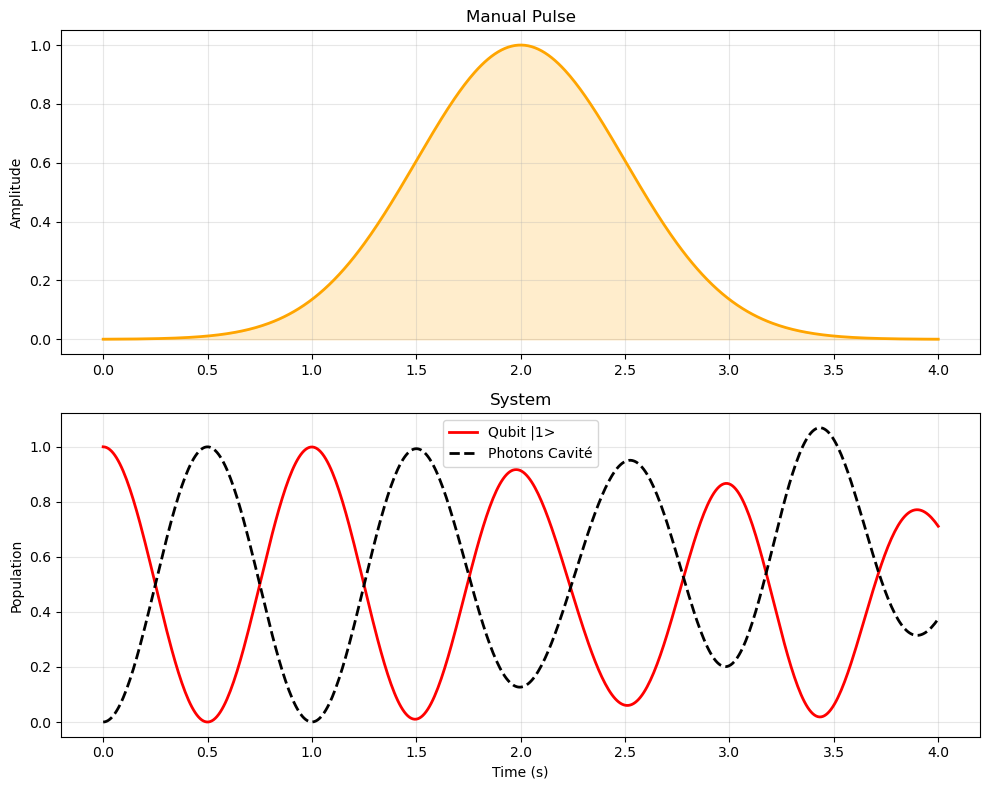

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, destroy, mesolve, tensor, qeye, expect, sigmay

N_cav = 3
g_int = 0.5 * (2*np.pi)  
T_sim = 4.0              

#Variable pulse
my_amp    = 1.0          
my_center = T_sim / 2.0  
my_width  = 0.5 

n_points = 500
tlist = np.linspace(0, T_sim, n_points)

def gaussian_pulse(t, amp, mu, sig):
    return amp * np.exp(-(t - mu)**2 / (2 * sig**2))
pulse_values = np.array([gaussian_pulse(t, my_amp, my_center, my_width) for t in tlist])

a  = tensor(qeye(2), destroy(N_cav))
sm = tensor(destroy(2), qeye(N_cav))
sy = tensor(sigmay(), qeye(N_cav)) 
H_int = g_int * (sm * a.dag() + sm.dag() * a)
H_total = [H_int, [sy, pulse_values]]
psi0 = tensor(basis(2, 1), basis(N_cav, 0))
sim = mesolve(H_total, psi0, tlist, [], [])

# Measures
pop_qubit = expect(tensor(basis(2,1)*basis(2,1).dag(), qeye(N_cav)), sim.states)
pop_cavity = expect(tensor(qeye(2), destroy(N_cav).dag()*destroy(N_cav)), sim.states)

# Graphics
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(tlist, pulse_values, 'orange', lw=2)
plt.fill_between(tlist, pulse_values, color='orange', alpha=0.2)
plt.title(f"Manual Pulse")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(tlist, pop_qubit, 'r', label='Qubit |1>', lw=2)
plt.plot(tlist, pop_cavity, 'k--', label='Photons Cavité', lw=2)
plt.title("System")
plt.xlabel("Time (s)")
plt.ylabel("Population")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("Non-Markovian response to manual pulse.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [8]:
def measure_non_markovianity(T_total, n_slices, g_val, pulse_params=None):
    tlist = np.linspace(0, T_total, n_slices)
    psi1_q = (basis(2,0) + basis(2,1)).unit()
    psi1_m = (basis(2,0) - basis(2,1)).unit()
    
    psi_cav = basis(N_cav, 0)
    
    psi1 = tensor(psi1_q, psi_cav)
    psi2 = tensor(psi1_m, psi_cav)
    
    a_q  = tensor(qeye(2), destroy(N_cav))
    sm_q = tensor(destroy(2), qeye(N_cav))
    sy_q = tensor(sigmay(), qeye(N_cav))
    
    H_int = g_val * (sm_q * a_q.dag() + sm_q.dag() * a_q)
    
    if pulse_params is not None:
        pulse_vals = np.array([pulse_func(t, pulse_params) for t in tlist], dtype=float)
        H_total = [H_int, [sy_q, pulse_vals]]
        label = "Avec Contrôle Optimisé"
    else:
        H_total = H_int
        label = "Libre (Sans Laser)"
    sim1 = mesolve(H_total, psi1, tlist, [], [])
    sim2 = mesolve(H_total, psi2, tlist, [], [])
    trace_dist = []
    for rho1, rho2 in zip(sim1.states, sim2.states):
        rho1_q = rho1.ptrace(0)
        rho2_q = rho2.ptrace(0)
        d = qutip.tracedist(rho1_q, rho2_q)
        trace_dist.append(d)
        
    return tlist, np.array(trace_dist), label

t, dist_free, lab_free = measure_non_markovianity(T_total, 100, g_int, pulse_params=None)
t, dist_opt, lab_opt = measure_non_markovianity(T_total, 100, g_int, pulse_params=res.x)

# --- GRAPHIQUE ---
#plt.figure(figsize=(10, 6))
#plt.plot(t, dist_free, 'k--', label=f"{lab_free} (Naturel)")
#plt.plot(t, dist_opt, 'g-', lw=2, label=f"{lab_opt}")

# Zone de Non-Markovianité (Quand la pente est positive)
#diff = np.diff(dist_free)
#for i, d in enumerate(diff):
#    if d > 0:
#        plt.axvspan(t[i], t[i+1], color='red', alpha=0.1)

#plt.title("Signature de la Non-Markovianité (Distance de Trace)")
#plt.xlabel("Temps (s)")
#plt.ylabel("Distinguabilité des états (D)")
#plt.legend()
#plt.grid(True, alpha=0.3)
#plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t, dist_free, 'k--', label=f"{lab_free} (Naturel)")
plt.plot(t, dist_opt, 'g-', lw=2, label=f"{lab_opt}")

added_label = False
diff = np.diff(dist_free)
for i, d in enumerate(diff):
    if d > 0:
        if not added_label:
            plt.axvspan(t[i], t[i+1], color='red', alpha=0.15, label='Information Backflow (Non-Markovian)')
            added_label = True
        else:
            plt.axvspan(t[i], t[i+1], color='red', alpha=0.15)

plt.title("Signature of Non-Markovianity via Trace Distance", fontsize=14)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel(r"Trace Distance $D(\rho_1, \rho_2)$", fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Signature of Non'Markovianity via Trace Distance.pdf", format="pdf", bbox_inches="tight")
plt.show()

NameError: name 'T_total' is not defined

 Démarrage JOPT avec Liouvillian (Correction Décohérence)...


/home/jomey/miniconda3/envs/fixed_jopt_env/lib/python3.13/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


   -> Fidélity : 0.983941


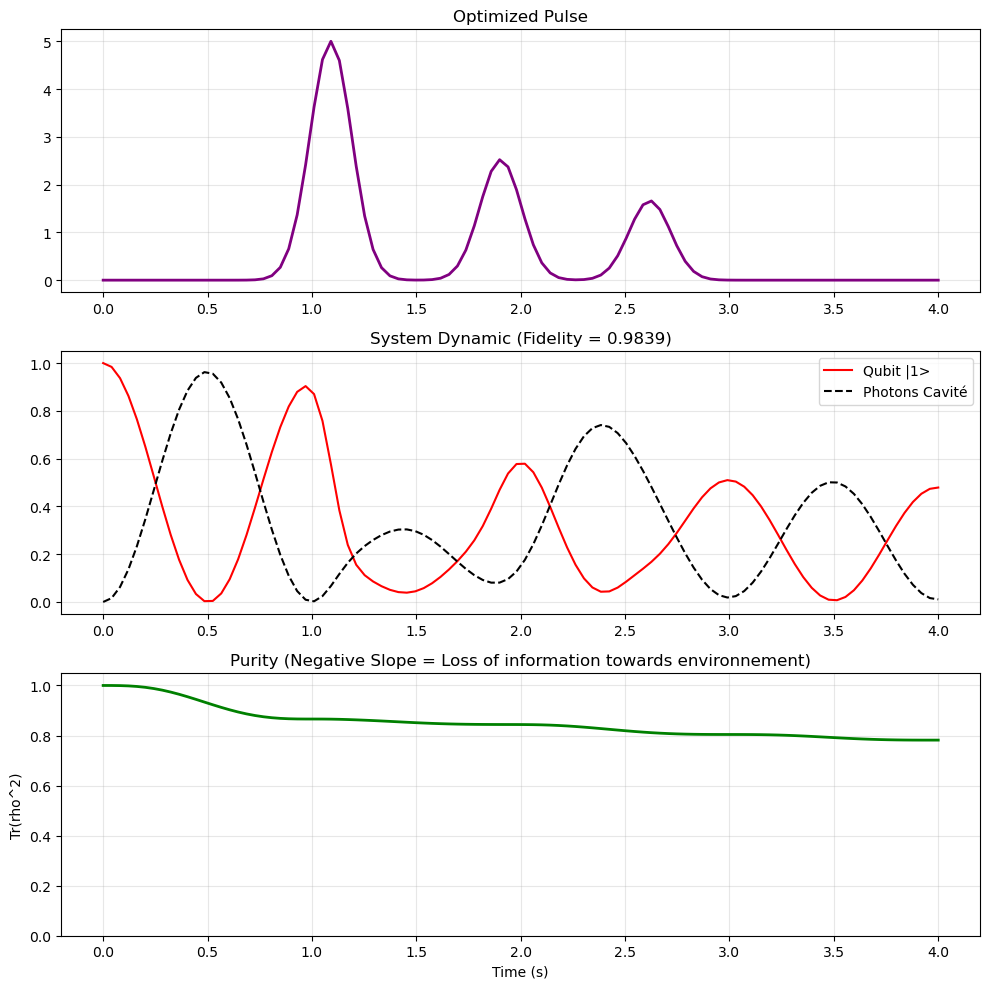

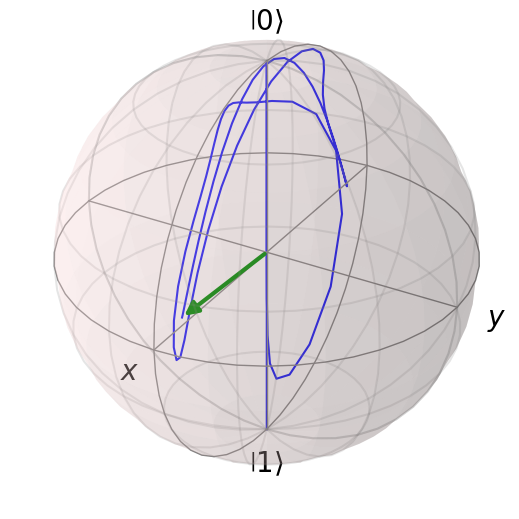

In [4]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import qutip
from qutip import tensor, basis, destroy, sigmay, qeye, expect, ket2dm, liouvillian, mesolve
import qutip_qoc as qoc

jax.config.update("jax_platform_name", "cpu")

print(" Démarrage JOPT avec Liouvillian (Correction Décohérence)...")

N_cav = 3
g_int = 0.5 * (2 * np.pi)
T_total = 4.0
times = np.linspace(0, T_total, 100)

kappa = 0.15  
gamma = 0.00  

a  = tensor(qeye(2), destroy(N_cav))
sm = tensor(destroy(2), qeye(N_cav))
H_drift = g_int * (sm * a.dag() + sm.dag() * a) 
H_c = tensor(sigmay(), qeye(N_cav))             

c_ops_list = [np.sqrt(gamma) * sm, np.sqrt(kappa) * a]

L_drift = liouvillian(H_drift, c_ops_list)

L_c = liouvillian(H_c) 

THETA = np.pi / 2   
PHI   = 0.0         
target_state_qobj = (np.cos(THETA/2) * basis(2,0) + 
                     np.exp(1j * PHI) * np.sin(THETA/2) * basis(2,1))

rho0 = ket2dm(tensor(basis(2, 1), basis(N_cav, 0)))
rho_targ = ket2dm(tensor(target_state_qobj, basis(N_cav, 0)))

@jax.jit
def multi_gaussian_jax(t, p, **kwargs):
    g1 = p[0] * jnp.exp(-(t - p[1])**2 / (2 * p[2]**2))
    g2 = p[3] * jnp.exp(-(t - p[4])**2 / (2 * p[5]**2))
    g3 = p[6] * jnp.exp(-(t - p[7])**2 / (2 * p[8]**2))
    return g1 + g2 + g3

H_model = [L_drift, [L_c, multi_gaussian_jax]]


guess_params = [
    2.0, T_total * 0.25, 0.2,
    2.0, T_total * 0.50, 0.2,
    2.0, T_total * 0.75, 0.2
]
bounds = [(-5.0, 5.0), (0.0, T_total), (0.1, T_total)] * 3

result = qoc.optimize_pulses(
    objectives=qoc.Objective(rho0, H_model, rho_targ),
    
    control_parameters={
        "pulse_Y": {
            "guess": guess_params,
            "bounds": bounds,
        }
    },
    tlist=times,
    algorithm_kwargs={
        "alg": "JOPT",
        "fid_err_targ": 1e-3, 
        "max_iter": 1000,
    }
)


print(f"   -> Fidélity : {1 - result.fid_err:.6f}")

opt_params = result.optimized_params[0]

def multi_gaussian_numpy(t, p):
    return (p[0] * np.exp(-(t - p[1])**2 / (2 * p[2]**2)) +
            p[3] * np.exp(-(t - p[4])**2 / (2 * p[5]**2)) +
            p[6] * np.exp(-(t - p[7])**2 / (2 * p[8]**2)))

opt_pulse = multi_gaussian_numpy(times, opt_params)
H_final_sim = [H_drift, [H_c, opt_pulse]]
sim = qutip.mesolve(H_final_sim, rho0, times, c_ops=c_ops_list) 

pop_qubit = expect(tensor(basis(2,1)*basis(2,1).dag(), qeye(N_cav)), sim.states)
pop_cav   = expect(tensor(qeye(2), destroy(N_cav).dag()*destroy(N_cav)), sim.states)
purity = [np.real((rho * rho).tr()) for rho in sim.states]

plt.figure(figsize=(10, 10))

# Pulse
plt.subplot(3, 1, 1)
plt.plot(times, opt_pulse, 'purple', lw=2)
plt.title("Optimized Pulse")
plt.grid(True, alpha=0.3)

# Dynamique
plt.subplot(3, 1, 2)
plt.plot(times, pop_qubit, 'r', label='Qubit |1>')
plt.plot(times, pop_cav, 'k--', label='Photons Cavité')
plt.title(f"System Dynamic (Fidelity = {1-result.fid_err:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)

# Purity
plt.subplot(3, 1, 3)
plt.plot(times, purity, 'g', lw=2)
plt.title("Purity (Negative Slope = Loss of information towards environnement)")
plt.xlabel("Time (s)")
plt.ylabel("Tr(rho^2)")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Fixed_JOPT_open_system.pdf", format="pdf", bbox_inches="tight")
plt.show()


#BLOCH SPHERE
b = qutip.Bloch()
rho_qubit = [rho0.ptrace(0) for rho0 in sim.states]
x = qutip.expect(qutip.sigmax(), rho_qubit)
y = qutip.expect(qutip.sigmay(), rho_qubit)
z = qutip.expect(qutip.sigmaz(), rho_qubit)
b.add_points([x, y, z], meth='l')
rho_final = sim.states[-1].ptrace(0)
b.add_states(rho_final, kind='vector')
b.show()

 Démarrage JOPT avec Liouvillian (Correction Décohérence)...


/home/jomey/miniconda3/envs/fixed_jopt_env/lib/python3.13/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


   -> Fidélité Finale visée : 0.983941


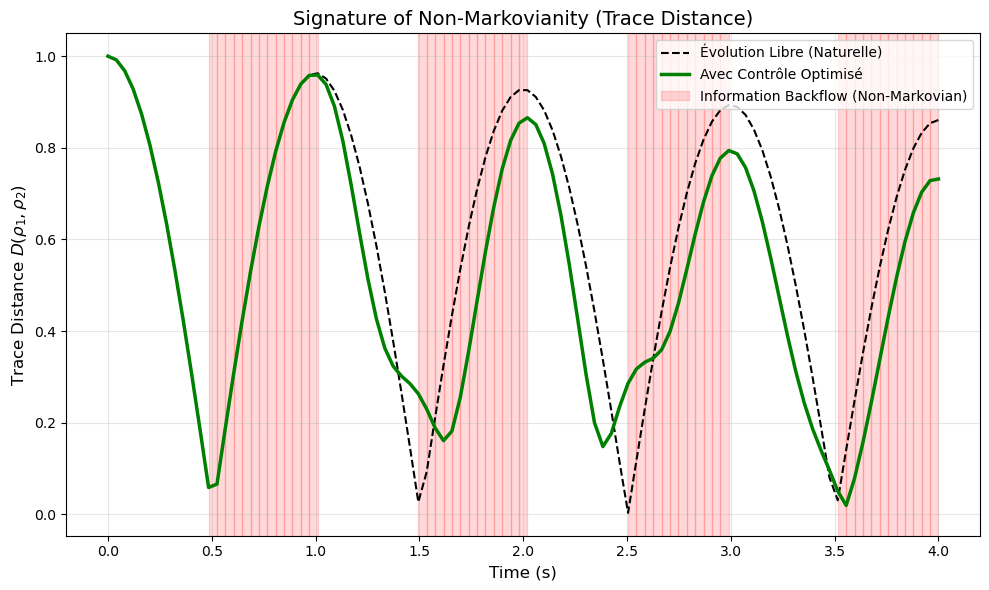

The BLP Measure is: 3.52


In [7]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import qutip
from qutip import tensor, basis, destroy, sigmay, qeye, expect, ket2dm, liouvillian, mesolve
import qutip_qoc as qoc

jax.config.update("jax_platform_name", "cpu")

print(" Démarrage JOPT avec Liouvillian (Correction Décohérence)...")

N_cav = 3
g_int = 0.5 * (2 * np.pi)
T_total = 4.0
times = np.linspace(0, T_total, 100)

kappa = 0.15  
gamma = 0.00  

a  = tensor(qeye(2), destroy(N_cav))
sm = tensor(destroy(2), qeye(N_cav))
H_drift = g_int * (sm * a.dag() + sm.dag() * a) 
H_c = tensor(sigmay(), qeye(N_cav))             

c_ops_list = [np.sqrt(gamma) * sm, np.sqrt(kappa) * a]

L_drift = liouvillian(H_drift, c_ops_list)

L_c = liouvillian(H_c) 

THETA = np.pi / 2   
PHI   = 0.0         
target_state_qobj = (np.cos(THETA/2) * basis(2,0) + 
                     np.exp(1j * PHI) * np.sin(THETA/2) * basis(2,1))

rho0 = ket2dm(tensor(basis(2, 1), basis(N_cav, 0)))
rho_targ = ket2dm(tensor(target_state_qobj, basis(N_cav, 0)))

@jax.jit
def multi_gaussian_jax(t, p, **kwargs):
    g1 = p[0] * jnp.exp(-(t - p[1])**2 / (2 * p[2]**2))
    g2 = p[3] * jnp.exp(-(t - p[4])**2 / (2 * p[5]**2))
    g3 = p[6] * jnp.exp(-(t - p[7])**2 / (2 * p[8]**2))
    return g1 + g2 + g3

H_model = [L_drift, [L_c, multi_gaussian_jax]]

guess_params = [
    2.0, T_total * 0.25, 0.2,
    2.0, T_total * 0.50, 0.2,
    2.0, T_total * 0.75, 0.2
]
bounds = [(-5.0, 5.0), (0.0, T_total), (0.1, T_total)] * 3

result = qoc.optimize_pulses(
    objectives=qoc.Objective(rho0, H_model, rho_targ),
    
    control_parameters={
        "pulse_Y": {
            "guess": guess_params,
            "bounds": bounds,
        }
    },
    tlist=times,
    algorithm_kwargs={
        "alg": "JOPT",
        "fid_err_targ": 1e-3, 
        "max_iter": 1000,
    }
)


# ==========================================
# 4. NON-MARKOVIANITY MEASURES (BLP)
# ==========================================
print(f"   -> Fidélité Finale visée : {1 - result.fid_err:.6f}")

opt_params = result.optimized_params[0]

def multi_gaussian_numpy(t, p):
    return (p[0] * np.exp(-(t - p[1])**2 / (2 * p[2]**2)) +
            p[3] * np.exp(-(t - p[4])**2 / (2 * p[5]**2)) +
            p[6] * np.exp(-(t - p[7])**2 / (2 * p[8]**2)))

def measure_blp(params=None):
    psi1 = tensor((basis(2,0) + basis(2,1)).unit(), basis(N_cav, 0))
    psi2 = tensor((basis(2,0) - basis(2,1)).unit(), basis(N_cav, 0))

    if params is not None:
        pulse_vals = multi_gaussian_numpy(times, params)
        H_sim = [H_drift, [H_c, pulse_vals]]
        label = "Avec Contrôle Optimisé"
    else:
        H_sim = H_drift
        label = "Évolution Libre (Naturelle)"
    sim1 = mesolve(H_sim, psi1, times, c_ops=c_ops_list)
    sim2 = mesolve(H_sim, psi2, times, c_ops=c_ops_list)

    trace_dist = []
    for r1, r2 in zip(sim1.states, sim2.states):
        rho1_q = r1.ptrace(0)
        rho2_q = r2.ptrace(0)
        trace_dist.append(qutip.tracedist(rho1_q, rho2_q))

    return times, np.array(trace_dist), label

t, dist_free, lab_free = measure_blp(params=None)
t, dist_opt, lab_opt  = measure_blp(params=opt_params)

plt.figure(figsize=(10, 6))
plt.plot(t, dist_free, 'k--', label=lab_free)
plt.plot(t, dist_opt, '#008000', lw=2.5, label=lab_opt)

added_label = False
diff = np.diff(dist_free)
for i, d in enumerate(diff):
    if d > 0: 
        if not added_label:
            plt.axvspan(t[i], t[i+1], color='red', alpha=0.15, label='Information Backflow (Non-Markovian)')
            added_label = True
        else:
            plt.axvspan(t[i], t[i+1], color='red', alpha=0.15)

plt.title("Signature of Non-Markovianity (Trace Distance)", fontsize=14)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel(r"Trace Distance $D(\rho_1, \rho_2)$", fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Signature of Non-Markovianity (Trace Distance).pdf", format="pdf", bbox_inches="tight")
#plt.savefig("Non-Markovianity (trace distance).pdf", format="pdf", bbox_inches="tight")
plt.show()
BLP_measure = np.sum(np.maximum(np.diff(dist_free), 0))
print(f"The BLP Measure is: {BLP_measure:.2f}")